In [6]:
import numpy as np
import matplotlib.pyplot as plt
import time
from numba import cuda


In [7]:
img = plt.imread("photo.jpg")
print(img.shape, img.dtype)


(651, 471, 3) uint8


In [8]:
h, w, _ = img.shape
pixelCount = h * w
flat = img.reshape(pixelCount, 3)
print(pixelCount, flat.shape)


306621 (306621, 3)


In [9]:
start = time.time()

grayCPU = np.zeros((pixelCount, 3), np.uint8)
for i in range(pixelCount):
    g = (int(flat[i, 0]) + int(flat[i, 1]) + int(flat[i, 2])) // 3
    grayCPU[i, 0] = g
    grayCPU[i, 1] = g
    grayCPU[i, 2] = g

cpuTime = time.time() - start
print("CPU time:", cpuTime, "s")


CPU time: 0.3957200050354004 s


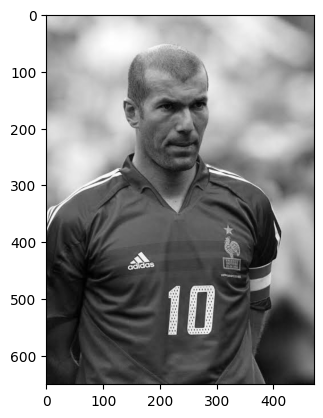

In [10]:
plt.imshow(grayCPU.reshape(h, w, 3))
plt.show()
plt.imsave("gray_cpu.png", grayCPU.reshape(h, w, 3))


In [11]:
@cuda.jit
def grayscale(src, dst):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    if tidx < src.shape[0]:
        g = np.uint8((src[tidx, 0] + src[tidx, 1] + src[tidx, 2]) / 3)
        dst[tidx, 0] = g
        dst[tidx, 1] = g
        dst[tidx, 2] = g


In [12]:
!nvidia-smi


Tue Sep 29 13:34:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             16W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [13]:
devSrc = cuda.to_device(flat)
devDst = cuda.device_array((pixelCount, 3), np.uint8)


In [14]:
blockSize = 64
gridSize = (pixelCount + blockSize - 1) // blockSize

grayscale[gridSize, blockSize](devSrc, devDst)
cuda.synchronize()

start = time.time()
grayscale[gridSize, blockSize](devSrc, devDst)
cuda.synchronize()
gpuTime = time.time() - start

print("GPU time:", gpuTime, "s")
print("Speedup:", cpuTime / gpuTime)


GPU time: 0.00040411949157714844 s
Speedup: 979.2153392330383


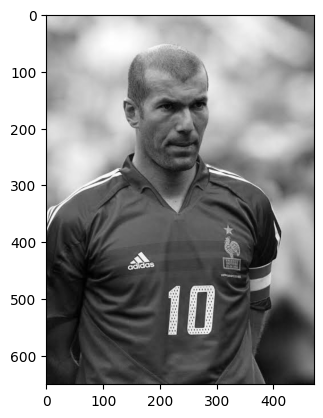

In [15]:
grayGPU = devDst.copy_to_host()
plt.imshow(grayGPU.reshape(h, w, 3))
plt.show()
plt.imsave("gray_gpu.png", grayGPU.reshape(h, w, 3))


32 9.141206741333008e-05
64 7.842302322387695e-05
128 7.787942886352539e-05
256 7.810115814208984e-05
512 7.825374603271485e-05
1024 8.825302124023438e-05


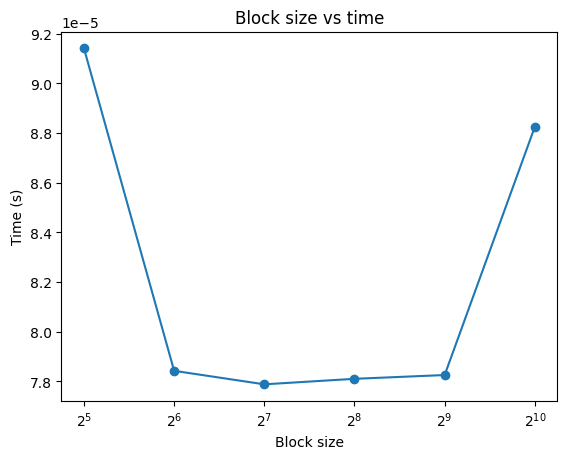

In [17]:
blockSizes = [32, 64, 128, 256, 512, 1024]
times = []

for bs in blockSizes:
    gs = (pixelCount + bs - 1) // bs
    grayscale[gs, bs](devSrc, devDst)
    cuda.synchronize()

    start = time.time()
    for r in range(100):
        grayscale[gs, bs](devSrc, devDst)
    cuda.synchronize()
    t = (time.time() - start) / 100

    times.append(t)
    print(bs, t)

plt.plot(blockSizes, times, marker="o")
plt.xscale("log", base=2)
plt.xlabel("Block size")
plt.ylabel("Time (s)")
plt.title("Block size vs time")
plt.savefig("blocksize_vs_time.png")
plt.show()
